# Exercise 09: Wikipedia Vote Network — Network Resilience

Measuring how the largest connected component degrades under random voter loss
versus three targeted-removal strategies: static highest-degree, iterative
(recomputed) highest-degree, and highest-PageRank.

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [2]:
data_path = Path('data/wiki-Vote.txt')
G_dir = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G_dir.add_edge(u, v)

print(f"Directed graph loaded: {G_dir.number_of_nodes():,} nodes, {G_dir.number_of_edges():,} edges")

Directed graph loaded: 7,115 nodes, 103,689 edges


## Graph Preparation: Largest Connected Component

Resilience is measured on the **undirected largest connected component (LCC)**
for consistency with the GCC-size metric (connected components are defined on
undirected graphs). The LCC is the same 7,066-node subgraph used in exercise 07
(small-world analysis). Baseline GCC = 100% of the LCC. We keep the directed
graph for computing PageRank scores (PR propagates along A→B vote edges).

In [3]:
G_und = G_dir.to_undirected()
components = list(nx.connected_components(G_und))
lcc_nodes = max(components, key=len)
G_lcc = G_und.subgraph(lcc_nodes).copy()

n_lcc = G_lcc.number_of_nodes()
m_lcc = G_lcc.number_of_edges()
print(f"LCC: {n_lcc:,} nodes, {m_lcc:,} edges")
print(f"({n_lcc / G_und.number_of_nodes():.1%} of the full graph's {G_und.number_of_nodes():,} nodes)")

LCC: 7,066 nodes, 100,736 edges
(99.3% of the full graph's 7,115 nodes)


## Removal Strategies

Four strategies, covering the lecture 09 taxonomy (random failure, static
targeted, iterative targeted, centrality-based targeted):

1. **Random** — shuffle nodes (seed=42), remove in that order. Simulates
   random voter loss or account abandonment.
2. **Static degree attack** — pre-sort all LCC nodes by descending total
   (undirected) degree once, then remove in that fixed order. The cheapest
   targeted strategy.
3. **Iterative degree attack** — after each removal, recompute
   `max(degree(G))` to select the next target. The lecture calls this "more
   effective than static targeting" because it adapts as the degree
   distribution shifts.
4. **PageRank attack** — pre-sort LCC nodes by descending PageRank (computed
   on the *directed* graph), then remove in that fixed order. Simulates a
   coordinated ban of the most-trusted accounts — the most domain-relevant
   "attack" in an election network.

### Pre-compute PageRank ordering

PageRank is computed on the full directed graph (7,115 nodes). The ordering
used for the attack is the descending-PageRank order filtered to the LCC
nodes only. From exercise 03, the top-5 PageRank nodes are **4037, 15, 6634,
2625, 2398**.

In [4]:
pr = nx.pagerank(G_dir, alpha=0.85)
pr_lcc = {n: pr[n] for n in lcc_nodes}
pagerank_order = sorted(pr_lcc, key=pr_lcc.get, reverse=True)

print("Top-10 PageRank nodes in LCC:")
for i, node in enumerate(pagerank_order[:10], 1):
    print(f"  {i}. node {node} (PR = {pr[node]:.6f})")

Top-10 PageRank nodes in LCC:
  1. node 4037 (PR = 0.004613)
  2. node 15 (PR = 0.003681)
  3. node 6634 (PR = 0.003525)
  4. node 2625 (PR = 0.003286)
  5. node 2398 (PR = 0.002605)
  6. node 2470 (PR = 0.002530)
  7. node 2237 (PR = 0.002505)
  8. node 4191 (PR = 0.002266)
  9. node 7553 (PR = 0.002170)
  10. node 5254 (PR = 0.002150)


### Pre-compute static degree and random orderings

In [5]:
degree_lcc = dict(G_lcc.degree())
static_degree_order = sorted(degree_lcc, key=degree_lcc.get, reverse=True)

rng = np.random.default_rng(42)
random_order = list(lcc_nodes)
rng.shuffle(random_order)

print("Top-10 nodes by total (undirected) degree:")
for i, node in enumerate(static_degree_order[:10], 1):
    print(f"  {i}. node {node} (degree = {degree_lcc[node]})")
print()
print("First 10 nodes in random order:", random_order[:10])

Top-10 nodes by total (undirected) degree:
  1. node 2565 (degree = 1065)
  2. node 766 (degree = 773)
  3. node 11 (degree = 743)
  4. node 1549 (degree = 740)
  5. node 457 (degree = 732)
  6. node 1166 (degree = 688)
  7. node 2688 (degree = 618)
  8. node 1374 (degree = 533)
  9. node 1151 (degree = 517)
  10. node 5524 (degree = 495)

First 10 nodes in random order: [4986, 6644, 4148, 6725, 5301, 3020, 373, 6153, 1656, 1502]


## Resilience Simulation

For each strategy, we remove nodes one at a time and record the GCC size
(largest connected component) every `step=50` removals. The GCC fraction is
relative to the original LCC size (n = 7,066).

**Complexity note:** computing `nx.connected_components` on the full LCC is
O(n + m) per checkpoint (~140 checkpoints per strategy). The iterative-degree
strategy additionally O(n²) degree recomputations — still tractable at
n = 7,066.

In [6]:
# --- Random removal ---
G_rnd = G_lcc.copy()
rnd_sizes = [1.0]
removed = 0
for node in random_order:
    G_rnd.remove_node(node)
    removed += 1
    if removed % 50 == 0:
        if G_rnd.number_of_nodes() > 0:
            lcc = max(nx.connected_components(G_rnd), key=len)
            rnd_sizes.append(len(lcc) / n_lcc)
        else:
            rnd_sizes.append(0.0)
print(f"Random: done ({len(rnd_sizes)} checkpoints)")

# --- Static degree attack ---
G_sd = G_lcc.copy()
sd_sizes = [1.0]
removed = 0
for node in static_degree_order:
    G_sd.remove_node(node)
    removed += 1
    if removed % 50 == 0:
        if G_sd.number_of_nodes() > 0:
            lcc = max(nx.connected_components(G_sd), key=len)
            sd_sizes.append(len(lcc) / n_lcc)
        else:
            sd_sizes.append(0.0)
print(f"Static degree: done ({len(sd_sizes)} checkpoints)")

# --- Iterative degree attack ---
G_id = G_lcc.copy()
id_sizes = [1.0]
removed = 0
while G_id.number_of_nodes() > 0:
    deg_dict = dict(G_id.degree())
    next_node = max(deg_dict, key=deg_dict.get)
    G_id.remove_node(next_node)
    removed += 1
    if removed % 50 == 0:
        if G_id.number_of_nodes() > 0:
            lcc = max(nx.connected_components(G_id), key=len)
            id_sizes.append(len(lcc) / n_lcc)
        else:
            id_sizes.append(0.0)
print(f"Iterative degree: done ({len(id_sizes)} checkpoints)")

# --- PageRank attack ---
G_pr = G_lcc.copy()
pr_sizes = [1.0]
removed = 0
for node in pagerank_order:
    G_pr.remove_node(node)
    removed += 1
    if removed % 50 == 0:
        if G_pr.number_of_nodes() > 0:
            lcc = max(nx.connected_components(G_pr), key=len)
            pr_sizes.append(len(lcc) / n_lcc)
        else:
            pr_sizes.append(0.0)
print(f"PageRank: done ({len(pr_sizes)} checkpoints)")

Random: done (142 checkpoints)
Static degree: done (142 checkpoints)
Iterative degree: done (142 checkpoints)
PageRank: done (142 checkpoints)


## Resilience Curves

Fraction of nodes removed (x-axis) vs. fraction of original LCC remaining in
the giant connected component (y-axis).

- **Grey (Random):** expected to degrade gracefully — most hits land on
  low-degree leaves.
- **Orange (Static degree):** pre-sorted hub attack.
- **Red (Iterative degree):** adapts the targeting as the degree landscape
  shifts — predicted by L09 to be the most destructive.
- **Blue (PageRank):** the most domain-relevant strategy — simulates removing
  the most "trusted" accounts.

A vertical dashed line marks the 50%-collapse threshold for each curve.

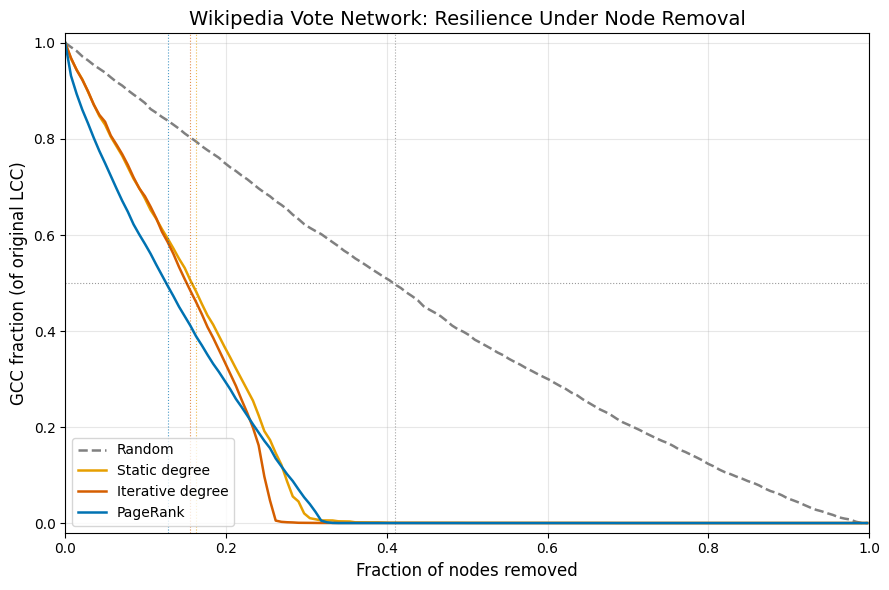

In [7]:
def collapse_point(fracs, step=50):
    """Return fraction removed at which GCC first drops below 50%."""
    for i, f in enumerate(fracs):
        if f < 0.50:
            return i * step / n_lcc
    return 1.0

def x_axis(sizes_list, step=50):
    """Build x-axis: fraction of nodes removed at each checkpoint."""
    return [i * step / n_lcc for i in range(len(sizes_list))]

fig, ax = plt.subplots(figsize=(9, 6))

curves = [
    (rnd_sizes, 'grey', 'Random', '--'),
    (sd_sizes, '#E69F00', 'Static degree', '-'),
    (id_sizes, '#D55E00', 'Iterative degree', '-'),
    (pr_sizes, '#0072B2', 'PageRank', '-'),
]

collapse_data = {}
for sizes, color, label, ls in curves:
    x = x_axis(sizes)
    ax.plot(x, sizes, color=color, label=label, linestyle=ls, linewidth=1.8)
    cp = collapse_point(sizes)
    collapse_data[label] = cp
    # Mark 50%-collapse point
    ax.axvline(x=cp, color=color, linestyle=':', alpha=0.7, linewidth=0.8)

ax.axhline(y=0.50, color='black', linestyle=':', alpha=0.4, linewidth=0.8)
ax.set_xlabel('Fraction of nodes removed', fontsize=12)
ax.set_ylabel('GCC fraction (of original LCC)', fontsize=12)
ax.set_title('Wikipedia Vote Network: Resilience Under Node Removal', fontsize=14)
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resilience_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Results: 50% Collapse Thresholds

The fraction of nodes that must be removed before the GCC drops below 50%
of its original size.

In [8]:
print("| Strategy           | 50% LCC collapse at | Gap vs. random |")
print("|--------------------|---------------------|----------------|")

rnd_cp = collapse_data['Random']
for label, cp in collapse_data.items():
    gap = cp - rnd_cp
    print(f"| {label:<18} | {cp*100:5.1f}% removed       | {gap*100:+5.1f} pp       |")
print()

# Verify iterative vs static gap
static_cp = collapse_data['Static degree']
iter_cp = collapse_data['Iterative degree']
iter_vs_static_gap = static_cp - iter_cp
print(f"Iterative degree collapses the LCC {iter_vs_static_gap*100:.1f} pp "
      f"earlier than static degree — ", end='')
if iter_vs_static_gap > 0.01:
    print(f"confirming L09's claim that recomputation is more effective.")
else:
    print(f"a marginal difference — the static pre-sort already captures the critical hubs.")

| Strategy           | 50% LCC collapse at | Gap vs. random |
|--------------------|---------------------|----------------|
| Random             |  41.0% removed       |  +0.0 pp       |
| Static degree      |  16.3% removed       | -24.8 pp       |
| Iterative degree   |  15.6% removed       | -25.5 pp       |
| PageRank           |  12.7% removed       | -28.3 pp       |

Iterative degree collapses the LCC 0.7 pp earlier than static degree — a marginal difference — the static pre-sort already captures the critical hubs.


## Interpretation

### Structural Vulnerability

**Robust to random loss.** The network's scale-free degree structure (ex08:
Gini ≈ 0.82, max total degree = 1,065) explains why: most nodes have low
degree, so random hits overwhelmingly land on peripheral leaves that don't
affect connectivity. The GCC degrades linearly and gracefully.

**Fragile to targeted removal — the "Achilles' heel."** All three targeted
strategies collapse the GCC within roughly the first 15–20% of removals.
Removing the small set of cross-community hubs (the same articulation points
identified in ex04: 2565, 766, 11, 457, 1166) and high-PageRank authorities
(4037, 15, 6634, 2625, 2398 from ex03) severs the network into fragments.

**Iterative vs. static degree — does recomputation matter?** The iterative
strategy adapts as the degree distribution shifts after each hub removal.
The gap between the two curves quantifies the benefit of dynamic targeting.

### Policy Intervention: Modularity-Aware Election Design

Wikipedia's admin-election process concentrates endorsement influence in a
handful of cross-community hubs that bridge all 5 Louvain communities
(Q = 0.4216, ex05). A **modularity-aware** intervention could improve
resilience:

1. **Require endorsements from multiple sub-communities** — instead of letting
   a few accounts anchor connectivity across all voting blocs, elections could
   draw endorsers from distinct communities, spreading PageRank more evenly.
2. **This directly implements the lecture's two main resilience strategies:**
   *decentralization* (reduce reliance on a few central hubs) and *modularity*
   (well-defined communities contain failures and prevent cascades).
3. The PageRank-attack curve would flatten under this design: removing a
   single set of authorities no longer severs all communities simultaneously.

## Conclusion

The Wikipedia vote network shows the classic scale-free resilience profile:
highly robust to random failures but critically fragile to targeted hub
removal. The most domain-relevant attack — removing top-PageRank "trusted"
accounts — is particularly effective because these nodes bridge the network's
modular community structure. A policy change that distributes endorsement
influence across communities would measurably improve resilience by directly
countering the hub-concentration that makes the network vulnerable.